**Final project Data Science**

Student Name : Marah Qandeel

Num : 2320226461



**Bank additional**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('bank-additional.csv')




df.head()



,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
df.isnull().sum()


,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
df.shape

df.duplicated().sum()
df = df.drop_duplicates()
df.shape

(4119, 21)

Check the number of "unknown" values ​​in each column

In [ ]:
for col in df.columns:
  if df[col].dtype =='object':
    print(col,(df[col]=='unknown').sum())




job 39
marital 11
education 167
default 803
housing 105
loan 105
contact 0
month 0
day_of_week 0
poutcome 0
y 0


In [ ]:
df['job'] = df['job'].replace('unknown', df['job'].mode()[0])
df['marital']=df['marital'].replace('unknown',df['marital'].mode()[0])
df['education']=df['education'].replace('unknown',df['education'].mode()[0])

df['default'] = df['default'].replace('unknown', 'not_available')

df['housing']=df['housing'].replace('unknown',df['housing'].mode()[0])
df['loan']=df['loan'].replace('unknown',df['loan'].mode()[0])
# للتاكد
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, (df[col] == 'unknown').sum())


job 0
marital 0
education 0
default 0
housing 0
loan 0
contact 0
month 0
day_of_week 0
poutcome 0
y 0


 Data Visualization

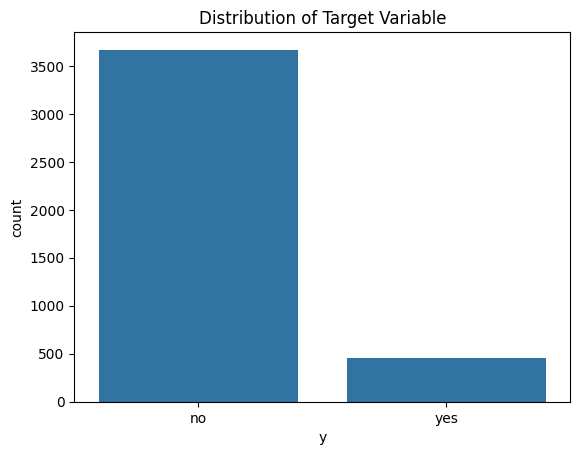

In [ ]:
sns.countplot(x='y',data=df)
plt.title('Distribution of Target Variable')
plt.show()

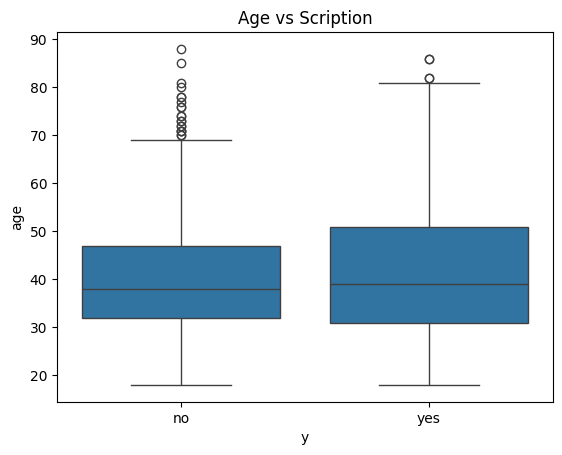

In [ ]:
sns.boxplot(x='y',y='age',data=df)
plt.title('Age vs Scription')
plt.show()

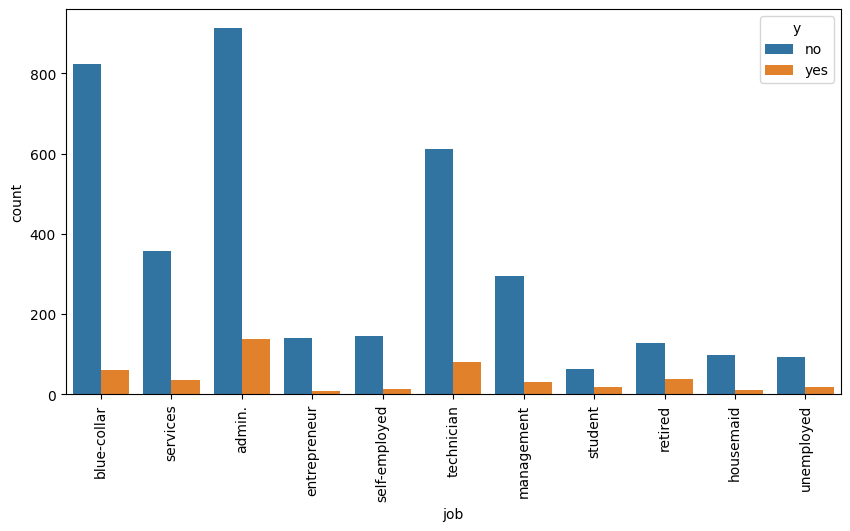

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=90)
plt.show()

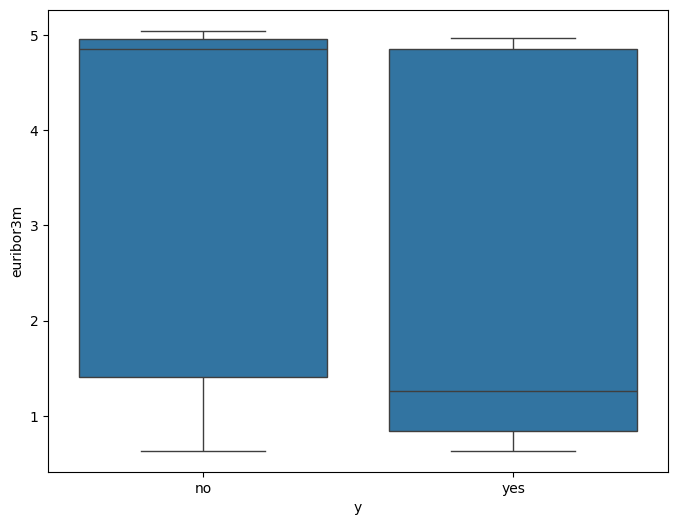

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='y',y='euribor3m',data =df)
plt.show()

One-Hot Encoding

In [ ]:
df['y'] = df['y'].map({'yes':1,'no':0})
df['y'].value_counts()




,count
y,
0,3668
1,451


In [ ]:



# لبقية الاعمدة الفئوية
df = pd.get_dummies(df, drop_first=True)

df.shape


(4119, 49)

scaling


In [ ]:
X = df.drop('y', axis=1)
y = df['y']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



logistic Regression
Logistic Regression is a supervised classification algorithm used for binary classification problems.
It predicts the probability that a sample belongs to a certain class (e.g., 0 or 1).



In [ ]:
from sklearn.linear_model import LogisticRegression

#Trian Model
model = LogisticRegression()
model.fit(X_train, y_train)


# prediction Model
y_pred = model.predict(X_test)




Model Evaluation Metrics
Accuracy
Measures the overall percentage of correct predictions made by the model.

Confusion Matrix
Shows the number of correct and incorrect predictions, divided into:

True Positives

True Negatives

False Positives

False Negatives
It helps us understand how the model makes mistakes.

Classification Report
Provides detailed evaluation metrics including:

Precision (how accurate positive predictions are)

Recall (how well the model detects actual positives)

F1-score (balance between precision and recall)



In [ ]:
#Evaluation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.904126213592233
Confusion Matrix:
 [[707  25]
 [ 54  38]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95       732
           1       0.60      0.41      0.49        92

    accuracy                           0.90       824
   macro avg       0.77      0.69      0.72       824
weighted avg       0.89      0.90      0.90       824



the model achieved an accuracy of 90%, which appears high. However, the dataset is imbalanced, so accuracy alone is not sufficient to evaluate performance.

From the confusion matrix, the model correctly predicted 707 non-subscribers and 38 subscribers. However, it failed to detect 54 actual subscribers, resulting in a recall of 41% for class 1.

This indicates that the model performs well in identifying non-subscribers but struggles to correctly detect potential subscribers.

